____
### 0. Preamble
- This serves as a continuation to my other notebook files where models are trained in a plain environment
- Within this notebook file, I will be experimenting with a world model version of the 
- I will also be documenting my learnings from the paper : https://worldmodels.github.io/

____
### 1. Feedforward network vs Recurrent Neural Networks (RNN)

#### 1.2 Feedforward networks
- All neural networks implemented thus far are all **feedforward network** (`nn.Sequential` of `nn.Linear` layers). 
- **Feedforward networks** have no memory: given an input, they compute an output, and that's it(Nothing about the computation depends on what inputs came before.)
    - Feeding in the same `obs_t` in twice in a row, obtains the exact same output twice — there's no notion of "time" or "history" built into the architecture itself. 
    - This is fine for the PPO/TD3/SAC agents because the environment is already Markovian: 
    - `obs = [inventory, days_left, last_demand]` fully captures everything the policy needs to act optimally at that instant, so there's nothing useful left in the *history* of observations that isn't already summarized in the current one.

#### 1.3 Recurrent Neural Network (RNN)
- **Recurrent Neural Network (RNN)** carries a hidden state $h_t$ forward from one step to the next
    - The hidden state is updated as a function of both the new input and the previous hidden state:
            $$h_t = f(x_t, h_{t-1})$$
    - This means the network's output at time $t$ can depend on everything it has seen since the start of the sequence, not just the current input
    - Feed it the same $x_t$ twice in a row at two different points in a sequence, and you can get two different outputs, because $h_{t-1}$ was different each time.

| | Feedforward (e.g. `PPOActorCritic`) | Recurrent (e.g. `MDNRNN`) |
|---|---|---|
| Input → Output | `y = f(x)` | `y_t = f(x_t, h_{t-1})` |
| Memory | None — stateless | Hidden state $h_t$ carried across steps |
| Good for | Tasks where the current input already contains everything needed (Markovian state) | Tasks where what happened *before* matters — sequences, time series, language |
| In this notebook | The policy/value networks for PPO, TD3, SAC | The MDN-RNN world model (M), which needs to remember *trends* across many steps to predict the future |
    


```python
# Feedforward layer: stateless, same weights applied independently each call
linear = nn.Linear(in_features, out_features)
y = linear(x)                     # y depends only on x

# Recurrent layer: stateful, hidden state threads through calls
lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
out, (h, c) = lstm(x, (h_prev, c_prev))   # out depends on x AND h_prev
```

____
### 2. Context for World model

#### 2.1 Components of a World model
- There are 3 components to creating a world model 
    1. Vision Model (V)
        - Meant to encode overly complex environment state features into a single z vector
        - Can be used in reverse to encode z vectors ($z$) back into the complex environment 
        - $z_t$ refers to the z vector at timestep $t$
    2. Predictive Model (M)
        - Takes in input z vectors from V and generates future z vectors that V is expected to produce
        - Essentially predicting the next state of the environment
    3. Controller (C)
        - Reads the z vector and any hidden state vectors to produce an output action 


#### 2.2 Dream Environments
- Dream environments are created using M and decoded using V where necessary 
- How a Dream environment is constructed
    1. Produce a probability distribution of $z_{t+1}$ given a specefic $z_t$
    2. Sample a $z_{t+1}$ and use sample as a real observation
    3. Producing a distribution of $z_{t+1}$ creates a "dream environment"
- Therefore a Dream environment is created using the predictive model (M) which produces a state (represented by $z_t$)
    - predictive model (M) also needs to generate a binary indicator to indicate if the episode is done ($d_t$)
    - ie, M($z_t$, $d_t$) -> $z_{t+1}$, $d_{t+1}$
- Usually no V model is required to decode/encode the z vectors as the controller (C) model is able to read the state (only needs decoding for humans to read)

#### 2.3 Training inside Dreams
- Predictive Model (M) used to simulate RNN is RNN(Recurrent-Neural-Network) based
    - RNNs read a hidden state vector and essentially retains 'memory', generating the next z vector based on the previous states and hidden states (refer to the top)
- Thus RNNs help M to predict the next state ($z_{t+1}$, $d_{t+1}$) properly, mimicing a complete game environment
    - If environment consists of pixels, M will have to learn from only raw image data collected from random episodes
- The environment can be made more challenging for training by adjusting the temperature parameter $T$
    -  This is done by increasing $T$ during the sampling process of $z_{t+1}$

#### 2.4 Exploting Virtual Environment
1. M is only an appropriate probabilistic model of the environment (a probabilistic model that mimics the actual environment)
    - Occassionally generate states that don't follow the laws governing the actual environment
2. Controller is given full access to hidden states of M
    - Since the agent is trained using M, it is given access to the hidden states on top of the observable z vectors
    - Therefore the agent is granted access to all internal states and memory of the game engine instead of ONLY game observations
- Therefore agents can efficiently explore ways to directly manipulate hidden states of teh game engine when training to maximize expected cumulative results
- If model finds an adversarial policy that can fool the dynamics model  
    - The model looks good under virtual environment but performs poorly in an actual environment
    - This is because the model visits states where the model is wrong as they are away from training distribution (game states or states that are not within the regular training distribution)
3. Solution for Exploitation
    - use Mixture density RNN (MDNRNN) which approximates the environment to a stochastic one, even if it is deterministic
        - This allows controller (C) to train inside a stochastic environment
    - Adjust temperature parameter $T$ to control randomness
        - The higher the $T$ the more uncertain the environment is, preventing C from taking advantage of imperfections of world model
        - Higher $T$ also trains the model to handle noise better when thrown into the real environment

____
### 3. Imports

In [2]:
import gymnasium as gym
import numpy as np
import torch as torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

____
### 4. Import Original Environment

In [3]:
class DynamicPricingEnv(gym.Env):
    def __init__(self):
        self.max_steps = 30
        self.max_inventory = 100
        self.cost = 5.0
        self.observation_space = gym.spaces.Box( #observation is given by [inventory, days left, number of units sold last]
            low=np.array([0, 0, 0]),
            high=np.array([self.max_inventory, self.max_steps, self.max_inventory]),
            dtype=np.float32
        )
        self.action_space = gym.spaces.Box(low=5.0, high=50.0, shape=(1,), dtype=np.float32)
        #action is a discrete number between 5 to 50
        self.latest = np.array([self.max_inventory, self.max_steps, 0], dtype=np.float32)

    def reset(self, seed=None, options=None): #resets the values in the state
        self.inventory = self.max_inventory 
        self.step_count = 0
        self.last_demand = 0
        self.latest = self.obs()
        return self.obs(), {} #extra info dictionary is empty

    def step(self, action):
        price = float(action[0]) #obtain the price as a float
        demand = self.demand(price) #calculating demand from the price set
        units_sold = min(demand, self.inventory) #sell out 

        self.inventory -= units_sold #updated inventory
        self.step_count += 1 # step + 1
        self.last_demand = units_sold # updating last known demand

        reward = (price - self.cost) * units_sold #reward is the profit generated from that round
        reward = reward / 100.0
        terminated = self.inventory <= 0
        truncated = self.step_count >= self.max_steps
        if truncated and self.inventory > 0:
            reward -= self.inventory * 2.0  # $2 penalty per unsold unit
        self.latest = self.obs()
        return self.obs(), reward, terminated, truncated, {}

    def obs(self): #to obtain observation of the current state
        return np.array([self.inventory / self.max_inventory, # 0 to 1
                        (self.max_steps - self.step_count) / self.max_steps, # 0 to 1
                        self.last_demand / self.max_inventory] # 0 to 1
                        , dtype=np.float32)

    def get_latest(self):
        obs = self.latest
        print(f"Leftover Stock: {obs[0]} units, Days Left {obs[1]}, Sold Units: {obs[2]}")

    def demand(self, price):
        base = 40
        sensitivity = 0.8
        noise = np.random.normal(0, 2) #noise is random number from 0 to 3
        return int(max(0, base - sensitivity * price + noise))

#### 4.1 General Breakdown of Environment
1. General Stats
    - 30 steps per episode
    - Unit cost of $5
    - Price floor of $5 and price ceiling of $50 
2. Observation State
    - an array of 3 numbers, representing inventory, days left and number of units sold last
    - normalise to a number between 0 to 1
    - In the world model, this would be represented by the z vector with 3 numbers 
    - The V model will just be a simple function that reverses the normlisation
3. Rewards (Profit - Penalty)
    - Profit given by (price - 5) * units sold
    - Penalty given by 2 * units left

____
### 5. Creating Components

#### 5.1 Vision Model (V)
- Implemented as a simple function that reverses the normalisation of the state vector
- No need to implement as a seperate class 

In [4]:
state_min = np.array([0, 0, 0])
state_max = np.array([100, 30, 100])

In [5]:
def decode(state : torch.tensor) -> torch.tensor: # normalising to between ranges 0-1
    return state / torch.tensor(state_max) 

In [6]:
def encode(normalised: torch.tensor) -> torch.tensor:  # convert to tensor of raw numbers
    return normalised * torch.tensor(state_max)

#### 5.2 Buffer (component of M) 
- Rollout buffer to store trained episode data (`class Buffer`)
- Each episode is stored as dictionary in the structure
```python 
{'z': (T+1, obs_dim), 'a': (T, action_dim), 'done': (T,)}
```

In [7]:
class Buffer:
    def __init__(self, env : gym.Env, sampler=lambda env: env.action_space.sample(), capacity=2000): #max out at capacity of 2k
        self.capacity = capacity
        self.episodes = [] #empty array 
        self.position = 0 #index that the next training episode will occupy
        self.env = env
        self.sampler = sampler #random sampler

    def add(self, episode: dict): 
        if len(self.episodes) < self.capacity: #not yet at capacity 
            self.episodes.append(episode) 
        else: #at capacity
            self.episodes[self.position] = episode #replace at that position 
            self.position = (self.position + 1) % self.capacity #reset position

    def add_many(self, episodes: list): #helper for adding a list of training episodes at once
        for ep in episodes:
            self.add(ep)

    def sample_batch(self, batch_size, seq_len, device="cpu"):
        idxs = np.random.choice(len(self.episodes), size=batch_size, replace=True)
        z_in, a_in, z_target, done_target = [], [], [], []
        for i in idxs:
            ep = self.episodes[i]
            T = ep["a"].shape[0]
            z = ep["z"][:T]            # z_0 ... z_{T-1}
            z_next = ep["z"][1:T + 1]  # z_1 ... z_T
            a = self.normalize_action(ep["a"])
            d = ep["done"]
            z_in.append(Buffer.pad(z, seq_len))
            a_in.append(Buffer.pad(a, seq_len))
            z_target.append(Buffer.pad(z_next, seq_len))
            done_target.append(Buffer.pad(d.reshape(-1, 1), seq_len))
        z_in = torch.tensor(np.stack(z_in), device=device)
        a_in = torch.tensor(np.stack(a_in), device=device)
        z_target = torch.tensor(np.stack(z_target), device=device)
        done_target = torch.tensor(np.stack(done_target), device=device)
        return z_in, a_in, z_target, done_target
    
    def collect_rollouts(self, n_episodes=500): #collect episodes using the random sampler built in
        episodes = []
        for ep in range(n_episodes):
            obs, _ = self.env.reset() # reset() returns (obs, info) -- unpack it
            zs = [obs]  # seed with z_0, the starting observation
            actions, dones = [], []  # fresh per episode, not shared across episodes
            done = False  # must exist before the while-loop checks it
            while not done:
                rand_action = self.sampler(self.env)
                next_obs, reward, terminated, truncated, _ = self.env.step(rand_action)
                done = terminated or truncated
                actions.append(np.asarray(rand_action, dtype=np.float32))
                zs.append(next_obs)
                dones.append(float(done))
            episodes.append({
                "z": np.array(zs, dtype=np.float32),
                "a": np.array(actions, dtype=np.float32),
                "done": np.array(dones, dtype=np.float32),
            })
        return episodes

    def normalize_action(self, a):
        return (a - self.env.action_space.low) / (self.env.action_space.high - self.env.action_space.low) * 2.0 - 1.0

    @staticmethod
    def pad(arr, length):
        out = np.zeros((length,) + arr.shape[1:], dtype=np.float32)
        n = min(length, arr.shape[0])
        out[:n] = arr[:n]
        return out

    def __len__(self):
        return len(self.episodes)

##### 5.21 helper functions
- `normalize_action(self, a)` : normalize an action, converting it from the environment's action range to the range of (-1, 1)
- `pad(arr, length)` : pads an array to standardize length 

```python
def normalize_action(self, a):
    return (a - self.env.action_space.low) / (self.env.action_space.high - self.env.action_space.low) * 2.0 - 1.0
```
- `(a - self.env.action_space.low) / (self.env.action_space.high - self.env.action_space.low)` : scales from range of `action_space` into a fraction
- `* 2.0` : multiplies by 2 to make it equal value in the range (0, 2)
- `- 1.0` : shifts the value such that the the range becomes (-1, 1)

```python
def pad(arr, length):
    out = np.zeros((length,) + arr.shape[1:], dtype=np.float32)
    n = min(length, arr.shape[0])
    out[:n] = arr[:n]
    return out
```
- `out = np.zeros((length,) + arr.shape[1:], dtype=np.float32)` : creates an all-zero array, sized `(length, arr.shape[1:])`
    - `arr.shape[1:]` grabs every dimension of `arr` except the first 
    - ie, if `arr` is shaped `(5,3)` meaning 5 timesteps, 3 obs dimensions, `arr.shape[1:]` = `(3,)` and `out` has the shape `(length, 3)`  
- `n = min(length, arr.shape[0])` : figuring out how much of the real data can actually fit
    - `arr.shape[0]` is the actual number of timesteps in this specefic episode
- `out[:n] = arr[:n]` : copying over the data from arr into `out`
    - replaces array `out` from the start to the nth index with the array's data
    - everything else stays at 0 
    - this step also clips the data, meaning if the array has more data beyond the specified length, it is excluded as well

##### 5.22 `sample_batch`
- randomly selects a batch of training episodes to use 

```python
def sample_batch(self, batch_size, seq_len, device="cpu"):
    idxs = np.random.choice(len(self.episodes), size=batch_size, replace=True)
    z_in, a_in, z_target, done_target = [], [], [], []
```

- `idxs = np.random.choice(len(self.episodes), size=batch_size, replace=True)` : randomly picks `batch_size` episode indices from the `self.episodes` array
    - `replace=True` means the same episode can be picked more than once in a batch, in case number needed < number of episdoes inside self.episodes
- `z_in, a_in, z_target, done_target = [], [], [], []` : initialising empty arrays

```python
for i in idxs:
    ep = self.episodes[i]
    T = ep["a"].shape[0]
    z = ep["z"][:T]
    z_next = ep["z"][1:T + 1]  # z_1 ... z_T
    a = self.normalize_action(ep["a"])
    d = ep["done"]
    z_in.append(Buffer.pad(z, seq_len))
    a_in.append(Buffer.pad(a, seq_len))
    z_target.append(Buffer.pad(z_next, seq_len))
    done_target.append(Buffer.pad(d.reshape(-1, 1), seq_len))
```

- `for i in idxs`: iterating through all the episodes chosen by the index 
    - `ep = self.episodes[i]` accesses each episode by indexing 
- `T = ep["a"].shape[0]` : accesse the length of each episode (number of steps)
- `z = ep["z"][:T]` : accesses the state from the 0th to the T-1th step
- `z_next = ep["z"][1:T + 1]` : accesses the state from the 1st step to the T-th step
    - slicing `z` and `z_next` like this ensures that the values at each array corresponds to the zth and the z+1th step 
    - ie, `z[i]` is the state at the ith timestep annd `z_next[i]` is the state at the i+1th timestep  
- `a = self.normalize_action(ep["a"])` : to make training more stable
    - `ep["a"]` is a number from 5 to 50 and `z` is an array with numbers from 0 to 1
    - later on, where `x = torch.cat([z, a], dim=-1)`, x will look like `[0.85, 0.6, 0.12, 35.0]` with 3 numbers under 1 and one number thats alot larger
    - During training, NNs are sensitive to the relative scale of input features and a feature thats numerically larger than the others tend to dominate the early gradients
    - If unnormalized, the NN has to effectively "discover" on its own that this one feature has to be down-weighted and place at a lower importance, causing training to be slower and less stable as a result
    - therefore `a` has to be normalized to between -1 and 1 such that all 4 numbers are close within the same range 
- `d = ep["done"]` : accesses the binary indicator that indicates if the episode is complete
- `z_in.append(Buffer.pad(z, seq_len)` : applies padding to the data
    - `Buffer.pad(z, seq_len)` builds a zero-filled array of exactly `seq_len` number of rows and copies as much of the real data as it fits
    - cuts off excess data and pads the array with zeroes if missing data
- `a_in.append(Buffer.pad(a, seq_len))` , `z_target.append(Buffer.pad(z_next, seq_len))` , `done_target.append(Buffer.pad(d.reshape(-1, 1), seq_len))` : applies padding to all the arrays for an episode

```python
z_in = torch.tensor(np.stack(z_in), device=device)
a_in = torch.tensor(np.stack(a_in), device=device)
z_target = torch.tensor(np.stack(z_target), device=device)
done_target = torch.tensor(np.stack(done_target), device=device)
return z_in, a_in, z_target, done_target
```
- `z_in = torch.tensor(np.stack(z_in), device=device)` : converts the lists into a tensor ready to be used 
    - `z_in` is originally a python list containing seperate numpy arrays, each shaped `(seq_len, obs_dim)`  
    - `np.stack` takes the list of sperate arrays into one single array with a new dimension added, making its shape `(batch_size, seq_len, obs_dim)`
    - `torch.tensor()` changes the data into a tensor and places it inside the device
- `a_in = torch.tensor(np.stack(a_in), device=device)`, `z_target = torch.tensor(np.stack(z_target), device=device)`, `done_target = torch.tensor(np.stack(done_target), device=device)` : applies the same changes to the rest of the list of arrays 

#### 5.3 Predictive Model (M)
- Engine for prediction implemented as a Mixture Density RNN (`class MDNRNN`)

In [8]:
class MDNRNN(nn.Module):
    def __init__(self, env: gym.Env, hidden_size=128, n_gaussians=5):
        super().__init__()
        self.obs_dim = env.observation_space.shape[0]  
        self.action_dim = env.action_space.shape[0]
        self.hidden_size = hidden_size
        self.n_gaussians = n_gaussians
        input_dim = self.obs_dim + self.action_dim
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True) 
        # MDN head: for each of K gaussians, need (pi, mu, sigma) per obs_dim
        K = n_gaussians
        self.pi_head = nn.Linear(hidden_size, K)
        self.mu_head = nn.Linear(hidden_size, K * self.obs_dim)
        self.sigma_head = nn.Linear(hidden_size, K * self.obs_dim)
        self.done_head = nn.Linear(hidden_size, 1) # done predictor: simple Bernoulli logit (paper uses a >50% cutoff rather than sampling, "more stable" than sampling from Bernoulli)
        #buffer for storing episodes

    def forward(self, z, a, hidden=None):
        x = torch.cat([z, a], dim=-1)
        out, hidden = self.lstm(x, hidden)  # out: (batch, seq_len, hidden_size)
        K, D = self.n_gaussians, self.obs_dim
        pi = torch.softmax(self.pi_head(out), dim=-1)
        mu = self.mu_head(out).view(*out.shape[:-1], K, D)
        sigma = torch.exp(self.sigma_head(out)).clamp(min=1e-4).view(*out.shape[:-1], K, D)
        done_logit = self.done_head(out)
        return pi, mu, sigma, done_logit, hidden
 
    def sample(self, pi, mu, sigma, temperature=1.0):
        batch = pi.shape[0]
        K, D = mu.shape[1], mu.shape[2]
        logits = torch.log(pi.clamp(min=1e-8)) / temperature # temperature-adjusted mixture weights (softmax with temp) and stds
        pi_t = torch.softmax(logits, dim=-1)
        sigma_t = sigma * np.sqrt(temperature)
        # pick a component per batch row
        comp = torch.multinomial(pi_t, num_samples=1).squeeze(-1)  # (batch,)
        idx = comp.view(batch, 1, 1).expand(batch, 1, D)
        chosen_mu = mu.gather(1, idx).squeeze(1)        # (batch, D)
        chosen_sigma = sigma_t.gather(1, idx).squeeze(1)  # (batch, D)
        eps = torch.randn_like(chosen_mu)
        z_next = chosen_mu + eps * chosen_sigma
        return z_next

    @staticmethod
    def mdn_loss(pi, mu, sigma, target):
        target = target.unsqueeze(2)  # (batch, seq_len, 1, D)
        # per-component, per-dim log prob, summed over D (factored gaussian,
        log_prob = -0.5 * (((target - mu) / sigma) ** 2 + 2 * torch.log(sigma) + np.log(2 * np.pi))
        log_prob = log_prob.sum(dim=-1)  # (batch, seq_len, K)
        log_pi = torch.log(pi.clamp(min=1e-8))
        log_mix = torch.logsumexp(log_pi + log_prob, dim=-1)  # (batch, seq_len)
        return -log_mix.mean()
 
    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
        return (h0, c0)

##### 5.31 Initialisation
 
```python
def __init__(self, env: gym.Env, hidden_size=128, n_gaussians=5):
    super().__init__()
    self.obs_dim = env.observation_space.shape[0]  
    self.action_dim = env.action_space.shape[0]
    self.hidden_size = hidden_size
    self.n_gaussians = n_gaussians 
    input_dim = self.obs_dim + self.action_dim
    self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True) 
```
- `env : gym.Env` is the environment the MDNRNN is trying to mimic
- `self.obs_dim = env.observation_space.shape[0]` , `self.action_dim = env.action_space.shape[0]` : the observation dimenstion and action dimension of the action 
- `self.hidden_size = hidden_size` : refers to the size of the hidden state vector
    - The entire history of an episode gets squeezed into a vector of 128 numbers by default
    - The larger the side of the hidden state vector, the larger the model's capacity to represent complex temporal patterns, but more parameters to train, slower to train, and easier to overfit on a small dataset of rollouts.
- `self.n_gaussians = n_gaussians` : the number of gaussian components that make up the predicted mixture distribution for $z_{t+1}$
- `self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)` : a Long Short Term Memory (LSTM) is a specefic type of RNN

```python
K = n_gaussians
self.pi_head = nn.Linear(hidden_size, K)
self.mu_head = nn.Linear(hidden_size, K * obs_dim)
self.sigma_head = nn.Linear(hidden_size, K * obs_dim)
self.done_head = nn.Linear(hidden_size, 1)
```
- `K = n_gaussians` : stores the number of gaussian components as K
- `self.pi_head = nn.Linear(hidden_size, K)` : a Linear model that transforms the hidden state into K values, each number in the vector representing a weight
    - each weight represents the probability of the next state landing near that cluster
- `self.mu_head = nn.Linear(hidden_size, K * obs_dim)`: a Linear layer that transforms the hidden state into a vector of `K * obs_dim` values (applied independently at every batch/timestep position)
    - every `obs_dim`-sized chunk of that output represents one of the K candidate next-states
    - each number within that chunk is the predicted mean for one dimension of the observation (inventory, days_left, or last_demand)
    - this effectively generates K mean vectors, each of size `obs_dim`, one per gaussian component in the mixture
- `self.sigma_head = nn.Linear(hidden_size, K * obs_dim)` : a Linear layer that transforms the hidden state into a vector of `K * obs_dim` values (applied independently at every batch/timestep position)
    - same explanation just that each value represents the standard deviation of the corresponding mean value

- Therefore, instead of predicting a single gaussian (one mean, one spread) for the next state, the MDN predicts K separate gaussians plus a weight (pi) for each, saying "the next state could land near this cluster with this probability, or near that cluster with that probability." 
    - calling `sample()`, picks one of the K components (weighted by pi) and then samples from that specific gaussian.

- `self.done_head = nn.Linear(hidden_size, 1)` : a Linear layer that transforms the hidden state into a single binary value, representing whether the episode is complete


##### 5.32 `forward()`
- Receives a state and action and returns gaussian components and state indicator
- State `z` and action `a`, both in the form of tensors 
    - `z` is of the shape `(batch, seq_len, obs_dim)`
    - `a` is of the shape `(batch, seq_len, actionn_dim)`
- Gaussian components : `pi`, `mu`, `sigma`
    - State indicator : `done_logit`

``` python
def forward(self, z, a, hidden=None):
    x = torch.cat([z, a], dim=-1)
    out, hidden = self.lstm(x, hidden)
```
- `torch.cat([z, a], dim=-1)`: glues the state vector and action vector together side by side, so the LSTM sees them as one combined input at each timestep. 
    - If `z = (batch, seq_len, 3)` and `a = (batch, seq_len, 1)`, `x = (batch, seq_len, 4).`
- `out, hidden = self.lstm(x, hidden)` : feeds x and hidden into the LSTM over the whole sequence.
    - hidden is the hidden state from before this sequence started
    - default value of `hidden = None` since the first call does not have any hidden states yet  
    - The LSTM internally steps through each timestep, updating its hidden state as it goes, and returns `out` and `hidden`
    - `out` represents the hidden state at every timestep ((batch, seq_len, hidden_size)) 
    - `hidden` represents the final hidden state after the last timestep in the sequence.

```python
K, D = self.n_gaussians, self.obs_dim
pi = torch.softmax(self.pi_head(out), dim=-1)
mu = self.mu_head(out).view(*out.shape[:-1], K, D)
sigma = torch.exp(self.sigma_head(out)).clamp(min=1e-4).view(*out.shape[:-1], K, D)
done_logit = self.done_head(out)
```
- `pi = torch.softmax(self.pi_head(out), dim=-1)` : reads from `out` and returns a vector with K values 
    - `torch.softmax()` is used to guarantee that the numbers inside the vector obtained are all positive and add up to 1 since the values in pi represents weights and are all probabilities
- `mu = self.mu_head(out).view(*out.shape[:-1], K, D)` : reads from `out` and returns an output with K components and D dimensions per component
    - `.view(*out.shape[:-1], K, D)` is used to view the values without constraining the values
    - the parameters `K, D` makes the output easily indexable : Kth component, D dimensions
- `sigma = torch.exp(self.sigma_head(out)).clamp(min=1e-4).view(*out.shape[:-1], K, D)` : reads from `out` and returns an output with K components and D dimensions per component
    - `torch.exp()` is used to make the standard deviation +ve since $e^x$ > 0 for all real values of x
    - `.clamp(min=1e-4)` adds a hard floor on the values so it never gets numerically close to zero
    - `.view(*out.shape[:-1], K, D)` is used to view the values without constraining the values
    - the parameters `K, D` makes the output easily indexable : Kth component, D dimensions
- `done_logit = self.done_head(out)` : reads from `out` and returns an output
    - no other functions needed as it is just a raw product

```python
return pi, mu, sigma, done_logit, hidden
```
- pi: `(batch, seq_len, K)`
- mu: `(batch, seq_len, K, obs_dim)`
- sigma: `(batch, seq_len, K, obs_dim)`
- done_logit: `(batch, seq_len, 1)`

##### 5.33 `sample()`
- Receives gaussian components and a temperature parameter and returns the next state vector
- Gaussian components: `pi`, `mu`, `sigma` which makes up the distribution
    - pi : `(batch, seq_len, K)`
    - mu: `(batch, seq_len, K, obs_dim)`
    - sigma: `(batch, seq_len, K, obs_dim)`
- Temperature parameter is used to control the randomness of the sampling and determines how unpredictable the general environment is
    - applied to `pi` : increases / decreases the differences in logit, making the selection of gaussian more random 
    - applied to `sigma` : increases / decreases the standard deviation of every gaussian, increasing/decreasing noise
- Turns distributions into one concrete z_{t+1} that can feed back into the environment loop.

```python
def sample(self, pi, mu, sigma, temperature=1.0):
    batch = pi.shape[0]
    K, D = mu.shape[1], mu.shape[2]
```
- `batch = pi.shape[0]` and `K, D = mu.shape[1], mu.shape[2]` : reads off the dimension size from the tensors so it is not hardcoded for the rest of the function

```python
logits = torch.log(pi.clamp(min=1e-8)) / temperature
pi_t = torch.softmax(logits, dim=-1)
sigma_t = sigma * np.sqrt(temperature)
```
- `torch.log(pi.clamp(min=1e-8)) / temperature` : logs the values within the pi tensor and implements a floor of `1e-8`  and divides it by temperature
    - applying `log()` converts it to logit space 
    - dividing by temperature stretches/compresses the logits 
- `pi_t = torch.softmax(logits, dim=-1)` : applying `softmax()` converts the whole logit tensor back into proper probability so that the all the numbers add up to 1
    - temperature < 1 : dividing by a fraction amplifies the logit differences, making `pi_t` more peaked , making the already more likely components more dominant (less randomness since more obvious)
    - temperature > 1 : flattens the distribution towards uniform, components become equally more likely and more ranndomness in which one gets picked (more ranndomness)
- `sigma_t = sigma * np.sqrt(temperature)` : seperately scales how spread out each individual gaussian is 
    - temperature > 1: sigma increases, distribution becomes wider, more noise
    - temperature < 1: sigma decreases, distribution becomes narrower, less noise

```python
comp = torch.multinomial(pi_t, num_samples=1).squeeze(-1)  # (batch,)
idx = comp.view(batch, 1, 1).expand(batch, 1, D)
chosen_mu = mu.gather(1, idx).squeeze(1)        # (batch, D)
chosen_sigma = sigma_t.gather(1, idx).squeeze(1)  # (batch, D)
eps = torch.randn_like(chosen_mu)
z_next = chosen_mu + eps * chosen_sigma
return z_next
```

- `comp = torch.multinomial(pi_t, num_samples=1).squeeze(-1)` : chooses the exact gaussian to use based on the `pi_t` tensor that stores the processed probability of all gaussians 
    - `torch.multinomial()` treats each row of `pi_t` as a probability distribution over K outcomes and draws one random index per batch row, weighted by those probabilities.
    - `.squeeze(-1)` removes a redundant size-1 dimension multinomial leaves behind, squeezing it from `(batch, 1)` to just `(batch,)`
    - therefore `comp` is just a flat list of chosen indices, one per batch row with shape (batch,)
- `idx = comp.view(batch, 1, 1).expand(batch, 1, D)` : reshapes the chosen indices
    - `.view(batch, 1, 1)` turns comp into the shape `(batch, 1, 1)`
    - `.expand(batch, 1, D)` repeats that single index across all D positions to indicate that the same index should be used to choose the mean and standard deviaton to obtain the distribution to be used
- `chosen_mu = mu.gather(1, idx).squeeze(1)` : chooses the `mu` (mean) to use
    - `.gather(1, idx)` picks out, along dimension 1 (the K dimension)
    -  i.e., "for batch row 0, give me mu[0, comp[0], :]; for batch row 1, give me mu[1, comp[1], :]," so on and so forth for all batch rows simultaneously.
    - `.squeeze(1)` removes the leftover size-1 dimension from the gather, squeezing the shape from `(batch, 1, D)` to `(batch, D)`
- `chosen_sigma = sigma_t.gather(1, idx).squeeze(1)` : chooses the `sigma` (processed standard deviation) to use
    - same process as the top
- `eps = torch.randn_like(chosen_mu)` : creates a tensor with same shape as `chosen_mu` with random numbers from a normal distribution of mean = 0 and var = 1
    - this is used to obtain a normal distribution of noise values, but with the same number of values as what is inside `chosen_mu`
- `z_next = chosen_mu + eps * chosen_sigma` : creates the distribution
    - `eps * chosen_sigma` does elementwise multiplication to scale the distribution
    - `chosen_mu + ` shifts the value 
    - returns `z_next` as the randomly sampled next state vector


##### 5.34 `mdn_loss()`
- calculate the loss value which is being minimized during training
- what train_mdnrnn backpropagates through
- ie, given the model's predicted mixture, how surprised should it by by the actual observed next state
- returns the negative log-likelihood of `target` under the predicted mixture.
- if the true target lands right on top of a high-weight, confident (small sigma) gaussian, loss is low.
- if the true target lands far from every predicted component, or the model was overconfident about the wrong place, loss is high.

```python
@staticmethod
def mdn_loss(pi, mu, sigma, target):
    target = target.unsqueeze(2)  
    log_prob = -0.5 * (((target - mu) / sigma) ** 2 + 2 * torch.log(sigma) + np.log(2 * np.pi))
    log_prob = log_prob.sum(dim=-1)  # (batch, seq_len, K)
    log_pi = torch.log(pi.clamp(min=1e-8))
    log_mix = torch.logsumexp(log_pi + log_prob, dim=-1)  # (batch, seq_len)
    return -log_mix.mean()
```

- `target = target.unsqueeze(2)` : adds a dimension so target with shape `(batch, seq_len, D)` can be compared against mu/sigma with shape `(batch, seq_len, K, D)` via broadcasting
    - i.e., compare the one true value against all K predicted components simultaneously
- `log_prob = -0.5 * (((target - mu) / sigma) ** 2 + 2 * torch.log(sigma) + np.log(2 * np.pi))` : the closed-form log-density of a gaussian
    - computing `-0.5 * ((x-mu)/sigma)^2 - log(sigma) - 0.5*log(2π)` per-dimension, 
- `log_prob = log_prob.sum(dim=-1)` : adds up the log-densities across the D dimensions
    - since the dimensions are treated as independent, multiplying probabilities = adding log-probabilities
- `log_pi = torch.log(pi.clamp(min=1e-8))` : applies `log()` and implements a floor of `1e-8`
- `log_mix = torch.logsumexp(log_pi + log_prob, dim=-1)` : combines "how likely is the target under component k" with "how much do we trust component k," summed 
    - `logsumexp()` is the numerically stable way to compute log(sum(exp(...))) over all K components 
    - this is the log-likelihood of the target under the whole mixture, not just one component.
- `return -log_mix.mean()` : returns the negative of this likelihood to change the maximisation problem into a minimisation problem 

##### 5.35 `init_hidden()`
- intitialises a pair of all-zero tensors shaped the way `nn.LSTM` expects its initial hidden/cell state: `(num_layers, batch_size, hidden_size)`

```python
def init_hidden(self, batch_size, device):
    h0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
    c0 = torch.zeros(1, batch_size, self.hidden_size, device=device)
    return (h0, c0)
```



### 6 Dream Environment 
- Wrapper class for the MDNRNN and Buffer instance to train the MDNRNN engine  
- Acts as a dream environment for an agent to step through
- Generalisable by simply feeding a `gym.Env` object in 

In [9]:
class DreamEnv(gym.Env):
    def __init__(self, env: gym.Env, calc_reward : callable, max_steps, capacity=2000, hidden_size=128, n_gaussians=5,
                 temperature=1.0, device="cpu", done_threshold=0.5, mdnloss_wt = 1, doneloss_wt = 1):
        self.env = env
        self.mdnrnn = MDNRNN(env, hidden_size=hidden_size, n_gaussians=n_gaussians)
        self.buffer = Buffer(env, capacity=capacity)
        self.device = device
        self.temperature = temperature
        self.observation_space = env.observation_space
        self.action_space = env.action_space
        self.initial_z = self.infer_initial_z(env)
        self.max_steps = max_steps
        self.done_threshold = done_threshold
        self.hidden = None
        self.z = None
        self.step_count = 0
        self.calc_reward = calc_reward
        self.mdnloss_wt = mdnloss_wt
        self.doneloss_wt = doneloss_wt

    def train(self, n_epochs=20, batch_size=32, seq_len=29, lr=1e-3,
              batches_per_epoch=50, render=False):
        if len(self.buffer) == 0:
            raise RuntimeError("DreamEnv.train() called with an empty buffer. Call collect_rollouts(...) and self.buffer.add_many(...) first.")
        self.mdnrnn.to(self.device)
        self.mdnrnn.train()
        optimizer = optim.Adam(self.mdnrnn.parameters(), lr=lr)
        bce = torch.nn.BCEWithLogitsLoss()
        for epoch in range(n_epochs):
            epoch_mdn_loss, epoch_done_loss = 0.0, 0.0
            for _ in range(batches_per_epoch):
                z_in, a_in, z_target, done_target = self.buffer.sample_batch(
                    batch_size, seq_len, self.device)
                hidden = self.mdnrnn.init_hidden(z_in.shape[0], self.device)
                pi, mu, sigma, done_logit, _ = self.mdnrnn(z_in, a_in, hidden)
                loss_mdn = self.mdnrnn.mdn_loss(pi, mu, sigma, z_target)
                loss_done = bce(done_logit, done_target)
                loss = self.mdnloss_wt*loss_mdn + self.doneloss_wt*loss_done
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.mdnrnn.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_mdn_loss += loss_mdn.item()
                epoch_done_loss += loss_done.item()
            if render:
                print(f"Epoch {epoch+1:>3}/{n_epochs} | "
                      f"MDN NLL: {epoch_mdn_loss/batches_per_epoch:.4f} | "
                      f"Done BCE: {epoch_done_loss/batches_per_epoch:.4f}")
        return self
    
    def evaluate(self, n_episodes=100, run_config=None):
        self.mdnrnn.eval()
        state_errors = []
        reward_errors = []
        done_correct = []
        for _ in range(n_episodes):
            obs, _ = self.env.reset()
            self.reset()
            done = False
            while not done:
                action = self.env.action_space.sample()
                real_next_obs, real_reward, real_terminated, real_truncated, _ = self.env.step(action)
                real_done = real_terminated or real_truncated
                z_prev = obs.copy()
                a_norm = self.buffer.normalize_action(action)
                z_t = torch.tensor(z_prev, dtype=torch.float32, device=self.device).view(1, 1, -1)
                a_t = torch.tensor(a_norm, dtype=torch.float32, device=self.device).view(1, 1, -1)
                with torch.no_grad():
                    hidden = self.mdnrnn.init_hidden(1, self.device)
                    pi, mu, sigma, done_logit, _ = self.mdnrnn(z_t, a_t, hidden)
                    pred_next_obs = (pi[:, 0].unsqueeze(-1) * mu[:, 0]).sum(dim=1)
                    pred_next_obs = pred_next_obs.squeeze(0).cpu().numpy()
                    pred_done_prob = torch.sigmoid(done_logit[0, 0, 0]).item()
                    pred_done = pred_done_prob > self.done_threshold
                pred_next_obs = np.clip(
                    pred_next_obs,
                    self.observation_space.low,
                    self.observation_space.high
                )

                pred_reward = self.calc_reward(z_prev, action, pred_next_obs, self.env, truncated=real_truncated)
                state_errors.append(np.abs(pred_next_obs - real_next_obs))
                reward_errors.append(abs(pred_reward - real_reward))
                done_correct.append(pred_done == real_done)
                obs = real_next_obs
                done = real_done
        state_errors = np.array(state_errors)
        results = {
            "state_mae_per_dim": state_errors.mean(axis=0).tolist(),
            "state_mae": float(state_errors.mean()),
            "reward_mae": float(np.mean(reward_errors)),
            "done_accuracy": float(np.mean(done_correct)),
            "n_episodes": int(n_episodes),
            "run_config": dict(run_config) if run_config is not None else {},
        }
        print("One-step DreamEnv evaluation")
        print(f"Mean absolute state error: {state_errors.mean(axis=0)}")
        print(f"Overall state MAE: {state_errors.mean():.4f}")
        print(f"Reward MAE: {np.mean(reward_errors):.4f}")
        print(f"Done accuracy: {np.mean(done_correct):.2%}")
        return results


    def reset(self, seed=None, options=None):
        self.mdnrnn.eval()
        self.hidden = self.mdnrnn.init_hidden(1, self.device)
        self.z = self.initial_z.copy()
        self.step_count = 0
        return self.z.copy(), {}
 
    def step(self, action):
        a = np.asarray(action, dtype=np.float32)
        a_norm = self.buffer.normalize_action(a)
        z_prev = self.z.copy()
        z_t = torch.tensor(self.z, dtype=torch.float32, device=self.device).view(1, 1, -1)
        a_t = torch.tensor(a_norm, dtype=torch.float32, device=self.device).view(1, 1, -1)
        with torch.no_grad():
            pi, mu, sigma, done_logit, self.hidden = self.mdnrnn(z_t, a_t, self.hidden)
            z_next = self.mdnrnn.sample(pi[:, 0], mu[:, 0], sigma[:, 0], temperature=self.temperature)
            done_prob = torch.sigmoid(done_logit[0, 0, 0]).item()
        z_next = z_next.squeeze(0).cpu().numpy()
        z_next = np.clip(z_next, self.observation_space.low, self.observation_space.high)
        reward = self.calc_reward(z_prev, action, z_next, self.env)
        self.step_count += 1
        terminated = done_prob > self.done_threshold
        truncated = self.step_count >= self.max_steps
        self.z = z_next
        return self.z.copy(), reward, terminated, truncated, {}
 
    def obs(self):
        return self.z.copy()
    
    @staticmethod
    def infer_initial_z(env): #helper to create initial state of the environment
        obs, _ = env.reset()
        return np.array(obs, dtype=np.float32)
    



#### 6.1 Initialisation
 
```python
def __init__(self, env: gym.Env, calc_reward: callable, max_steps, capacity=2000, hidden_size=128,              
    n_gaussians=5, temperature=1.0, device="cpu", done_threshold=0.5, mdnloss_wt = 1, doneloss_wt = 1):
    self.mdnrnn = MDNRNN(env, hidden_size=hidden_size, n_gaussians=n_gaussians)
    self.buffer = Buffer(env, capacity=capacity)
    self.device = device
    self.temperature = temperature
    self.observation_space = env.observation_space
    self.action_space = env.action_space
    self.initial_z = self.infer_initial_z(env)
    self.max_steps = max_steps
    self.done_threshold = done_threshold
    self.hidden = None
    self.z = None
    self.step_count = 0
    self.calc_reward = calc_reward
    self.mdnloss_wt = mdnloss_wt
    self.doneloss_wt = doneloss_wt
```
- `env : gym.Env` is the environment the dream environment is mimicing
- `self.mdnrnn = MDNRNN(env, hidden_size=hidden_size, n_gaussians=n_gaussians)` : building the MDNRNN
    - this acts as the engine for predicting and generating the next states
    - needs to be trained before the dream environment is an effective 'dream environment'
- `self.buffer = Buffer(env, capacity=capacity)` : creating the buffer that is used to store episode data for training the MDNRNN
- `self.temperature = temperature` : parameter to control the randomness of the sampling process
- `self.observation_space = env.observation_space` , `self.action_space = env.action_space` : recording the `observation_space` and `action_space`
    - these 2 attributes are required as the class inherits from the `gym.Env` class
- `self.initial_z = self.infer_initial_z(env)` : parameter to record the starting state of the environment
    - required when `reset()` is called
- `self.max_steps = max_steps` : the max number of steps the environment reaches before it is terminated
- `self.done_threshold = done_threshold` : the threshold for the done indicator
    - `MDNRNN` generates a value that indicates if the episode is done at each timestep
    - if the value exceeds threshold, the episode is taken to be terminated 
    - default value is at 0.5
- `self.hidden = None`, `self.z = None`, `self.step_count = 0` : initialising the empty default values
    - `self.hidden` refers to the hidden state
- `self.calc_reward = calc_reward` : used as the function to calculate the reward
- `self.mdnloss_wt = mdnloss_wt` , `self.doneloss_wt = doneloss_wt` : weights for the mdn_loss and done_loss in the combined loss equation 
    - default values of 1 for both so that both losses are equally prioritised by optimiser

#### 6.2 `infer_initial_z(env)`
- infers the start state of the dream environment by copying it from `env`

```python
@staticmethod
def infer_initial_z(env):
    obs, _ = env.reset() #calls reset on env to get the start state
    return np.array(obs, dtype=np.float32) #returns start state as an array 
```

#### 6.3 `train()`
- to train the MDNRNN so that it becomes an effective engine for predicting states 
- input parameters
    - `n_epochs` : the number of full passes over randomly sampled batches to run 
    - `batch_size` : the number of episodes that gets sampled per training step
    - `seq_len` : the fixed sequence length every sampled episode gets padded/truncated to 
    - `lr` : learning rate for the Adam optimizer
    - `batches_per_epoch` : how many random batches make up one reported 
- therefore, training loop runs for `n_epochs`, with `batches_per_epoch` batches per epoch 


```python
def train(self, n_epochs=20, batch_size=32, seq_len=29, lr=1e-3,
        batches_per_epoch=50, render=False):
    if len(self.buffer) == 0:
        raise RuntimeError("DreamEnv.train() called with an empty buffer. Call collect_rollouts(...) and self.buffer.add_many(...) first.")
```
- `if len(self.buffer) == 0: raise RuntimeError(...)` : throws an error if the buffer is empty 

```python
self.mdnrnn.to(self.device)
self.mdnrnn.train()  
optimizer = torch.optim.Adam(self.mdnrnn.parameters(), lr=lr)
bce = torch.nn.BCEWithLogitsLoss()
```
- `self.mdnrnn.to(self.device)` : registers the MDNRNN and its parameters to the device for training 
- `self.mdnrnn.train()` : switches the MDNRNN to training mode
- `optimizer = torch.optim.Adam(self.mdnrnn.parameters(), lr=lr)` : creates an adam optimizer with learning rate = `lr`
    - register all of the MDNRNN's parameters into the optimizer
- `bce = torch.nn.BCEWithLogitsLoss()`: bce is the loss function of the `done` prediction 
    - `BCEWithLogitsLoss()` expects raw logits as input instead of probabilities, which is what `done_logit` is

```python
for epoch in range(n_epochs):
    epoch_mdn_loss, epoch_done_loss = 0.0, 0.0
    for _ in range(batches_per_epoch):
```
- `for epoch in range(n_epochs)`: iterate for `n_epochs` times
- `epoch_mdn_loss, epoch_done_loss = 0.0, 0.0` : initialising empty parameters to store the MDN's loss and the done's loss for each epoch
- `for _ in range(batches_per_epoch)`: iterate for `batches_per_epoch` times inside 

```python
z_in, a_in, z_target, done_target = self.buffer.sample_batch(batch_size, seq_len, self.device)
hidden = self.mdnrnn.init_hidden(z_in.shape[0], self.device)
pi, mu, sigma, done_logit, _ = self.mdnrnn(z_in, a_in, hidden)
loss_mdn = self.mdnrnn.mdn_loss(pi, mu, sigma, z_target)
loss_done = bce(done_logit, done_target)
loss = loss_mdn + loss_done
```
- `z_in, a_in, z_target, done_target = self.buffer.sample_batch(batch_size, seq_len, self.device)` : pulls one fresh random batch from the buffer
    - batch is already processed and normalized correctly
- `hidden = self.mdnrnn.init_hidden(z_in.shape[0], self.device)` : creates a fresh array filled with zeroes to trachk the hidden state
- `pi, mu, sigma, done_logit, _ = self.mdnrnn(z_in, a_in, hidden)` : runs the full batch of sequences through `forward()` in one call
    - produces predictions at every single timestep
- `loss_mdn = self.mdnrnn.mdn_loss(pi, mu, sigma, z_target)`: loss function of the MDNRNN
    - `loss_mdn` measures how well the predicted mixture explains the actual next state
- `loss_done = bce(done_logit, done_target)` : loss function of the done indicator
    - measures how wellthe model predicts episode termination
- `loss = loss_mdn + loss_done` : combines the 2 loss values into 1 scalar
    - combining the 2 loss functions into 1 value with equal weight
    - the optimizer thus treats both objectives as equally important

```python
optimizer.zero_grad()
loss.backward()
torch.nn.utils.clip_grad_norm_(self.mdnrnn.parameters(), max_norm=1.0)
optimizer.step()
epoch_mdn_loss += loss_mdn.item()
epoch_done_loss += loss_done.item()
```
- `optimizer.zero_grad()` : clears old gradients
- `loss.backward()` : backpropagate the gradients through the combined loss function 
- `torch.nn.utils.clip_grad_norm_(self.mdnrnn.parameters(), max_norm=1.0)` : clips the gradient norms to at most 1.0
    - this is done for stability during training to prevent any single batch's gradients from making unusually large updates to the weights
- `optimizer.step()` : applying these gradient changes
- `epoch_mdn_loss += loss_mdn.item()` and `epoch_done_loss += loss_done.item()` : accumulates the value 
    - `.item()` pulls a plain python float out of the tensor for reporting purposes in the print line

```python
if render:
    print(f"Epoch {epoch+1:>3}/{n_epochs} | "
          f"MDN NLL: {epoch_mdn_loss/batches_per_epoch:.4f} | "                      
          f"Done BCE: {epoch_done_loss/batches_per_epoch:.4f}")
```
- `if render` : prints out the epoch's training data if set to true

#### 6.4 `reset()`
- since `DreamEnv` inherits from `gym.Env`, the reset method is required as part of the interface
- required to return an observation state and a dict

```python
def reset(self, seed=None, options=None):
    self.mdnrnn.eval()
    self.hidden = self.mdnrnn.init_hidden(1, self.device)
    self.z = self.initial_z.copy()
    self.step_count = 0
    return self.z.copy(), {}
```
- `self.mdnrnn.eval()` : switches the MDNRNN to evaluation mode
- `self.hidden = self.mdnrnn.init_hidden(1, self.device)` : resets the hidden state vector to a fresh initialised one
- `self.z = self.initial_z.copy()` : start state of the observation state
    - utilises `self.initial_z` which obtains the value from a helper
- `self.step_count = 0` : step count reset to 0   

#### 6.5 `step()`
- since `DreamEnv` inherits from `gym.Env`, the step method is required as part of the interface
- receives `action` and return the next state (z vector), reward, and the boolean flags `terminated` and `truncated`

```python
def step(self, action):
    a = np.asarray(action, dtype=np.float32)
    a_norm = self.buffer.normalize_action(a)
    z_prev = self.z.copy()
```
- `a = np.asarray(action, dtype=np.float32)` : converts the action into an array 
- `a_norm = self.buffer.normalize_action(a)` : normalizes the action for training stability
- `z_prev = self.z.copy()` : storing the current state before the next one is generated

```python
z_t = torch.tensor(self.z, dtype=torch.float32, device=self.device).view(1, 1, -1)
a_t = torch.tensor(a_norm, dtype=torch.float32, device=self.device).view(1, 1, -1)
```
- `z_t = torch.tensor(self.z, dtype=torch.float32, device=self.device).view(1, 1, -1)` : builds the step tensor for the observation state
    - uses `self.z` as that is the current state the environment is in 
    - `.view(1, 1, -1)` reshapes it to have `batch size = 1`, `sequence length = 1` and whatever's left is put as the third item. 
    - in this case, "whatever's left" is the 3 numbers in the observation state 
    - this makes `z_t` shaped as `(1, 1, 3)`
- `a_t = torch.tensor(a_norm, dtype=torch.float32, device=self.device).view(1, 1, -1)` : builds the step tensor for the action input
    - same as the top, but "whatever's left" is the 1 number in the action input
    - this makes `a_t` shaped as `(1, 1, 1)`

```python
with torch.no_grad():
    pi, mu, sigma, done_logit, self.hidden = self.mdnrnn(z_t, a_t, self.hidden)
    z_next = self.mdnrnn.sample(pi[:, 0], mu[:, 0], sigma[:, 0], temperature=self.temperature)
    done_prob = torch.sigmoid(done_logit[0, 0, 0]).item() 
    z_next = z_next.squeeze(0).cpu().numpy()
    z_next = np.clip(z_next, self.observation_space.low, self.observation_space.high)
    reward = self.calc_reward(z_prev, action, z_next, self.env)
    self.step_count += 1
    terminated = done_prob > self.done_threshold
    truncated = self.step_count >= self.max_steps
    self.z = z_next
    return self.z.copy(), reward, terminated, truncated, {}
```

- `with torch.no_grad()` : turns off gradient tracking 
- `pi, mu, sigma, done_logit, self.hidden = self.mdnrnn(z_t, a_t, self.hidden)` : feeds the formatted state (`z_t`) , formatted action (`a_t`) and hidden state (`self.hidden`) into the MDNRNN
    - obtains the gaussian components `pi`, `mu`, `sigma` and `done_logit` as the log probability for the termination indicator
    - the hidden state vector is automatically assigned as `self.hidden` so that it is accumulated
- `z_next = self.mdnrnn.sample(pi[:, 0], mu[:, 0], sigma[:, 0], temperature=self.temperature)` : samples the gaussian components to obtain the next state 
    - slicing `[:,0]` for the gaussian components to solve shape mismatch
    - `pi` is shaped `(batch, seq_len, K)` and `mu`/`sigma` is shaped `(batch, seq_len, K, D)`
    - slicing `[:,0]` keeps the batch dimension as is (`:`) and pick out index 0 so that `seq_len` is removed
    - `temperature = self.temperature` is done to control the randomness of the sampling, determining how difficult the environment is 
- `done_prob = torch.sigmoid(done_logit[0, 0, 0]).item()` : obtains the probability of the episode being terminated
    - slicing `[0,0,0]` to strip away the tensor and converts it into a 0-dimensional scalar tensor
    - `.item()` pulls a plain python float out of the tensor for reporting purposes in the print line 
- `z_next = z_next.squeeze(0).cpu().numpy()` : converts it 
    - `.squeeze(0)` removes the first dimension 
    - `.cpu()` moves the tensor to the cpu so that numpy can access it
    - `.numpy()` converts it to a numpy array
- `z_next = np.clip(z_next, self.observation_space.low, self.observation_space.high)` : ensures the next state vector does not exceed the allowable range of the environment
- `reward = self.calc_reward(z_prev, action, z_next, self.env)` : using the function that is initialised to calculate reward

- `self.step_count += 1` : progress `step_count`
- `terminated = done_prob > self.done_threshold` : checks `done_prob` against `self.done_threshold`
- `truncated = self.step_count >= self.max_steps` : checks the step count against the max steps 
- `self.z = z_next` : updates the state of the environment

### 6 Training MDNRNN as part of Dream Environment

In [10]:
env = DynamicPricingEnv()

In [11]:
def DynPriceReward(z_prev, action, z_next, env, truncated=False):
    price = float(action[0])
    units_sold = z_next[2] * env.max_inventory       
    inventory_after = z_next[0] * env.max_inventory  
    reward = (price - env.cost) * units_sold
    reward = reward / 100.0
    if truncated and inventory_after > 0:
        reward -= inventory_after * 2.0
    return reward

In [12]:
dreamEnv = DreamEnv(env, DynPriceReward, env.max_steps)


In [13]:
episodes = dreamEnv.buffer.collect_rollouts()
dreamEnv.buffer.add_many(episodes)

In [14]:
trainedEnv = dreamEnv.train(n_epochs=50, batch_size=32, seq_len=29, lr=1e-3, batches_per_epoch=1000, render=True)

Epoch   1/50 | MDN NLL: -6.0295 | Done BCE: 0.1919
Epoch   2/50 | MDN NLL: -7.0124 | Done BCE: 0.1824
Epoch   3/50 | MDN NLL: -6.6290 | Done BCE: 0.1742
Epoch   4/50 | MDN NLL: -7.8905 | Done BCE: 0.1626
Epoch   5/50 | MDN NLL: -8.6943 | Done BCE: 0.1522
Epoch   6/50 | MDN NLL: -8.3020 | Done BCE: 0.1419
Epoch   7/50 | MDN NLL: -9.4023 | Done BCE: 0.1287
Epoch   8/50 | MDN NLL: -10.2830 | Done BCE: 0.1097
Epoch   9/50 | MDN NLL: -9.9180 | Done BCE: 0.0894
Epoch  10/50 | MDN NLL: -9.4809 | Done BCE: 0.0713
Epoch  11/50 | MDN NLL: -10.3159 | Done BCE: 0.0580
Epoch  12/50 | MDN NLL: -10.2728 | Done BCE: 0.0484
Epoch  13/50 | MDN NLL: -10.8982 | Done BCE: 0.0408
Epoch  14/50 | MDN NLL: -10.9275 | Done BCE: 0.0371
Epoch  15/50 | MDN NLL: -11.1666 | Done BCE: 0.0339
Epoch  16/50 | MDN NLL: -11.2429 | Done BCE: 0.0296
Epoch  17/50 | MDN NLL: -11.7139 | Done BCE: 0.0261
Epoch  18/50 | MDN NLL: -11.8226 | Done BCE: 0.0239
Epoch  19/50 | MDN NLL: -10.2185 | Done BCE: 0.0327
Epoch  20/50 | MDN NL

In [15]:
results = trainedEnv.evaluate()

One-step DreamEnv evaluation
Mean absolute state error: [0.12774365 0.04765112 0.03588066]
Overall state MAE: 0.0704
Reward MAE: 0.6601
Done accuracy: 92.85%


### 7 Exploring parameters that affect accuracy and error
- Parameters to explore:
    1. Model Capacity 
        - `hidden_size` : dimension used to encapsulate temporal context
        - `n_gaussians` : number of sets of gaussian components to generate 
    2. Training regime
        - `n_epochs` & `batches_per_episode` : total number of gradient steps equals to the product of these 2 parameters. If the MDN NLL and Done BCE are still trending downwards at the end of training, can increase as the model is still training  
        - `batch_size` : smaller batches give noisier but more frequent updates, larger batches give smoother but fewer. With small dataset (a few hundred episodes), larger batch size risk each batch looking similar to the last, reducing the diversity each gradient step sees
    3. Data
        - `seq_len` : the length of every episode's data, set to max_steps-1 or just max_steps so that episode data does not get cut off
        - `capacity` of Buffer : how much data is collected before training 
    4. Loss weighting
        - `loss = loss_mdn * loss_wt + done_wt * loss_done` : the combined loss function currently has both loss components occupying an equal weight. Toggle with the settings inside to place more emphasis or less emphasis on either parts of the loss function

#### 7.1 Initialising set parameters:
1. Control : 
    - `hidden_size = 128`
    - `n_gaussians = 5`
    - `n_epochs = 20`
    - `batches_per_epoch = 100`
    - `batch_size = 32`
    - `seq_len = max - 1 (29)`
    - `capacity = 2000`
    - `loss_wt = 1`
    - `done_wt = 1`
2. Increasing hidden size: 
    - `hidden_size = 192`
    - `hidden_size = 256`
3. Increasing number of sets of gaussian components
    - `n_gaussians = 3`
    - `n_gaussians = 7`
4. Increasing number of epochs and number of batches per episode
    - n_epochs = 

In [16]:
control_params = {"hidden_size": 128, "n_gaussians": 5, "n_epochs": 20,
                  "batches_per_epoch": 100, "batch_size": 32, "seq_len": env.max_steps - 1,
                  "capacity": 2000, "loss_wt": 1, "done_wt": 1}

#### 7.2 Initialising function that train models and plots accuracy against variable

In [17]:
def train_list(params_list, n=3, n_eval_episodes=100, render=True):
    """
    Returns a list of groups -- one per param_set -- where each group is a dict:
        {'param_set': the original param dict, 
        'models':list of n trained DreamEnv instances}
    This structure lets plot_accuracy_vs_variable evaluate ALL n models per
    config and plot the mean +/- std, rather than selecting a single "best" run.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    all_groups = []
    for param_set in params_list:
        group = []
        for run_idx in range(n):
            if render:
                print(f"\n--- Param set {param_set} | Run {run_idx+1}/{n} ---")

            model = DreamEnv(
                env,
                DynPriceReward,
                env.max_steps,
                capacity=param_set["capacity"],
                hidden_size=param_set["hidden_size"],
                n_gaussians=param_set["n_gaussians"],
                temperature=1.0,
                device="cpu",
                done_threshold=0.5,
                mdnloss_wt=param_set["loss_wt"],
                doneloss_wt=param_set["done_wt"],
            )
            n_episodes = param_set.get("n_episodes", 500)
            episodes = model.buffer.collect_rollouts(n_episodes=n_episodes)
            model.buffer.add_many(episodes)

            trained = model.train(
                n_epochs=param_set["n_epochs"],
                batch_size=param_set["batch_size"],
                seq_len=param_set["seq_len"],
                lr=1e-3,
                batches_per_epoch=param_set["batches_per_epoch"],
                render=render,
            )
            trained.run_config = {**param_set, "repeat_idx": run_idx + 1, "n_repeats": n}
            group.append(trained)

        all_groups.append({"param_set": param_set, "models": group})

    return all_groups


In [18]:
def plot_accuracy_vs_variable(groups, variable_name, metric_name="done_accuracy",
                               n_eval_episodes=100, show_band=True, ax=None):
    """
    Given the output of train_list, evaluates every model in each group,
    averages the target metric across the n runs, and plots:
        - mean as a line with markers
        - +/- 1 std as a shaded band (if show_band=True and more than 1 x-value)

    variable_name: the param key to put on the x-axis (e.g. 'hidden_size')
    metric_name:   one of 'state_mae', 'reward_mae', 'done_accuracy'
    """
    x_values, means, stds = [], [], []

    for group in groups:
        param_set = group["param_set"]
        models = group["models"]

        x_value = param_set.get(variable_name)
        if x_value is None:
            raise KeyError(
                f"'{variable_name}' not found in param_set. "
                f"Available keys: {list(param_set.keys())}"
            )

        scores = []
        for model in models:
            result = model.evaluate(n_episodes=n_eval_episodes, run_config=param_set)
            if metric_name not in result:
                raise KeyError(
                    f"'{metric_name}' not found in evaluation result. "
                    f"Available: {list(result.keys())}"
                )
            scores.append(result[metric_name])

        x_values.append(x_value)
        means.append(np.mean(scores))
        stds.append(np.std(scores))
        print(
            f"{variable_name}={x_value}: "
            f"{metric_name} = {np.mean(scores):.4f} +/- {np.std(scores):.4f} "
            f"(over {len(scores)} runs)"
        )

    # sort by x so line plot is always clean regardless of param_set input order
    order = np.argsort(x_values)
    x_values = np.array(x_values)[order]
    means = np.array(means)[order]
    stds = np.array(stds)[order]

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))

    n_runs = len(groups[0]["models"])
    ax.plot(x_values, means, marker="o", label="mean")
    if show_band and len(x_values) > 1:
        ax.fill_between(x_values, means - stds, means + stds, alpha=0.2, label="+/- 1 std")
        ax.legend()
    ax.set_xlabel(variable_name)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} vs {variable_name} (mean over {n_runs} runs)")
    ax.grid(True, alpha=0.3)
    return ax

#### 7.3 Training the model

In [19]:
control = DreamEnv(
    env,
    DynPriceReward,
    env.max_steps,
    capacity=control_params["capacity"],
    hidden_size=control_params["hidden_size"],
    n_gaussians=control_params["n_gaussians"],
    temperature=1.0,
    device="cpu",
    done_threshold=0.5,
    mdnloss_wt=control_params["loss_wt"],
    doneloss_wt=control_params["done_wt"],
)

In [20]:
episodes = control.buffer.collect_rollouts()
control.buffer.add_many(episodes)

In [21]:
trainedcontrol = control.train(
    n_epochs=control_params["n_epochs"],
    batch_size=control_params["batch_size"],
    seq_len=control_params["seq_len"],
    lr=1e-3,
    batches_per_epoch=control_params["batches_per_epoch"],
    render=True,
)

Epoch   1/20 | MDN NLL: -3.0266 | Done BCE: 0.2703
Epoch   2/20 | MDN NLL: -6.5870 | Done BCE: 0.1864
Epoch   3/20 | MDN NLL: -7.1092 | Done BCE: 0.1856
Epoch   4/20 | MDN NLL: -5.8315 | Done BCE: 0.1853
Epoch   5/20 | MDN NLL: -7.2520 | Done BCE: 0.1855
Epoch   6/20 | MDN NLL: -7.7428 | Done BCE: 0.1856
Epoch   7/20 | MDN NLL: -7.4230 | Done BCE: 0.1849
Epoch   8/20 | MDN NLL: -6.6570 | Done BCE: 0.1843
Epoch   9/20 | MDN NLL: -6.6779 | Done BCE: 0.1843
Epoch  10/20 | MDN NLL: -6.5701 | Done BCE: 0.1838
Epoch  11/20 | MDN NLL: -7.1927 | Done BCE: 0.1839
Epoch  12/20 | MDN NLL: -7.1265 | Done BCE: 0.1840
Epoch  13/20 | MDN NLL: -7.2588 | Done BCE: 0.1833
Epoch  14/20 | MDN NLL: -5.9803 | Done BCE: 0.1833
Epoch  15/20 | MDN NLL: -6.9802 | Done BCE: 0.1827
Epoch  16/20 | MDN NLL: -7.3994 | Done BCE: 0.1824
Epoch  17/20 | MDN NLL: -6.4535 | Done BCE: 0.1821
Epoch  18/20 | MDN NLL: -6.2833 | Done BCE: 0.1814
Epoch  19/20 | MDN NLL: -7.2616 | Done BCE: 0.1805
Epoch  20/20 | MDN NLL: -7.9623

In [22]:
controlres = trainedcontrol.evaluate()

One-step DreamEnv evaluation
Mean absolute state error: [0.23167358 0.6317456  0.09685941]
Overall state MAE: 0.3201
Reward MAE: 1.4152
Done accuracy: 83.50%


#### Exploring hidden_size
- hs0: `hidden_size = 32`
- hs1 : `hidden_size = 64`
- control : `hidden_size = 128` 
- hs2 : `hidden_size = 96`
- hs3 : `hidden_size = 160`
- hs4 : `hidden_size = 192`
- hs5 : `hidden_size = 256`

In [40]:
hs0_params = {"hidden_size": 32,  "n_gaussians": 5, "n_epochs": 20, "batches_per_epoch": 100,
              "batch_size": 32, "seq_len": env.max_steps - 1, "capacity": 2000, "loss_wt": 1, "done_wt": 1}
hs1_params = {"hidden_size" : 64, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs2_params = {"hidden_size" : 96, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs3_params = {"hidden_size" : 160, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs4_params = {"hidden_size" : 192, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs5_params = {"hidden_size" : 224, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs6_params = {"hidden_size" : 256, "n_gaussians" : 5, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
hs_lst = [hs0_params, hs1_params, control_params, hs2_params, hs3_params, hs4_params, hs5_params, hs6_params]



--- Param set {'hidden_size': 32, 'n_gaussians': 5, 'n_epochs': 20, 'batches_per_epoch': 100, 'batch_size': 32, 'seq_len': 29, 'capacity': 2000, 'loss_wt': 1, 'done_wt': 1} | Run 1/10 ---
Epoch   1/20 | MDN NLL: -0.7420 | Done BCE: 0.4683
Epoch   2/20 | MDN NLL: -7.0104 | Done BCE: 0.2310
Epoch   3/20 | MDN NLL: -8.3519 | Done BCE: 0.2220
Epoch   4/20 | MDN NLL: -9.1070 | Done BCE: 0.2176
Epoch   5/20 | MDN NLL: -9.6619 | Done BCE: 0.2144
Epoch   6/20 | MDN NLL: -10.0589 | Done BCE: 0.2124
Epoch   7/20 | MDN NLL: -9.9387 | Done BCE: 0.2107
Epoch   8/20 | MDN NLL: -9.8394 | Done BCE: 0.2092
Epoch   9/20 | MDN NLL: -10.1435 | Done BCE: 0.2078
Epoch  10/20 | MDN NLL: -9.7635 | Done BCE: 0.2064
Epoch  11/20 | MDN NLL: -10.5055 | Done BCE: 0.2057
Epoch  12/20 | MDN NLL: -10.9801 | Done BCE: 0.2046
Epoch  13/20 | MDN NLL: -11.0538 | Done BCE: 0.2035
Epoch  14/20 | MDN NLL: -11.2373 | Done BCE: 0.2028
Epoch  15/20 | MDN NLL: -11.4953 | Done BCE: 0.2018
Epoch  16/20 | MDN NLL: -10.9497 | Done

<Axes: title={'center': 'done_accuracy vs hidden_size (mean over 10 runs)'}, xlabel='hidden_size', ylabel='done_accuracy'>

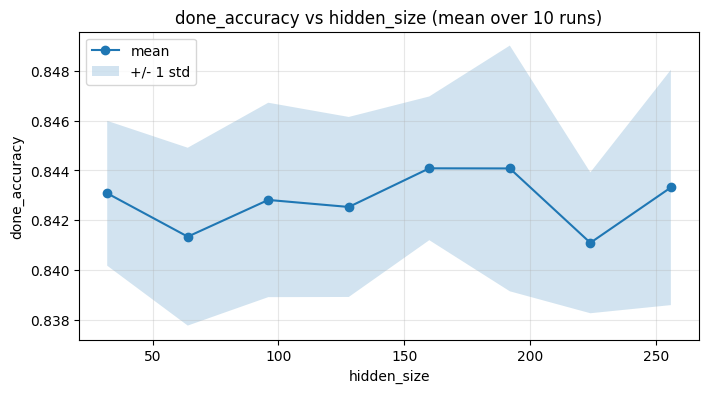

In [41]:
hs_groups = train_list(hs_lst, n=10)
plot_accuracy_vs_variable(hs_groups, "hidden_size")

#### Exploring number of gaussians
- ng1 : `n_gaussians = 3`
- ng2 : `n_gaussians = 4`
- control : `n_gaussians = 5`
- ng3 : `n_gaussians = 6`
- ng4 : `n_gaussians = 7`
- ng5 : `n_gaussians = 8`
- ng6 : `n_gaussians = 9`

In [42]:
ng1_params = {"hidden_size" : 128, "n_gaussians" : 3, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ng2_params = {"hidden_size" : 128, "n_gaussians" : 4, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ng3_params = {"hidden_size" : 128, "n_gaussians" : 6, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ng4_params = {"hidden_size" : 128, "n_gaussians" : 7, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ng5_params = {"hidden_size" : 128, "n_gaussians" : 8, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ng6_params = {"hidden_size" : 128, "n_gaussians" : 9, "n_epochs" : 20, "batches_per_epoch" : 100,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}

ng_lst = [ng1_params, ng2_params, control_params, ng3_params, ng4_params, ng5_params, ng6_params]


--- Param set {'hidden_size': 128, 'n_gaussians': 3, 'n_epochs': 20, 'batches_per_epoch': 100, 'batch_size': 32, 'seq_len': 29, 'capacity': 2000, 'loss_wt': 1, 'done_wt': 1} | Run 1/5 ---
Epoch   1/20 | MDN NLL: -2.0024 | Done BCE: 0.2680
Epoch   2/20 | MDN NLL: -6.1235 | Done BCE: 0.1837
Epoch   3/20 | MDN NLL: -6.8591 | Done BCE: 0.1837
Epoch   4/20 | MDN NLL: -5.9479 | Done BCE: 0.1836
Epoch   5/20 | MDN NLL: -6.9447 | Done BCE: 0.1840
Epoch   6/20 | MDN NLL: -6.8824 | Done BCE: 0.1842
Epoch   7/20 | MDN NLL: -6.2299 | Done BCE: 0.1841
Epoch   8/20 | MDN NLL: -6.2123 | Done BCE: 0.1844
Epoch   9/20 | MDN NLL: -6.6755 | Done BCE: 0.1847
Epoch  10/20 | MDN NLL: -7.6352 | Done BCE: 0.1847
Epoch  11/20 | MDN NLL: -7.8351 | Done BCE: 0.1846
Epoch  12/20 | MDN NLL: -7.1587 | Done BCE: 0.1846
Epoch  13/20 | MDN NLL: -7.2790 | Done BCE: 0.1845
Epoch  14/20 | MDN NLL: -6.9859 | Done BCE: 0.1835
Epoch  15/20 | MDN NLL: -6.6160 | Done BCE: 0.1832
Epoch  16/20 | MDN NLL: -8.6933 | Done BCE: 0.

<Axes: title={'center': 'done_accuracy vs n_gaussians (mean over 5 runs)'}, xlabel='n_gaussians', ylabel='done_accuracy'>

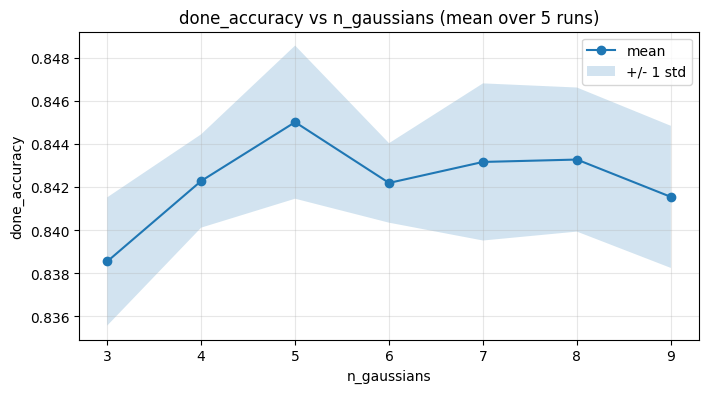

In [43]:
ng_group = train_list(ng_lst, 5)
plot_accuracy_vs_variable(ng_group, "n_gaussians")

#### Exploring number of epochs & number of batches per epoch
- every gradient step comes from one randomly-sampled batch, so what actually matters for how much the model has learned is the total number of gradient steps (`n_epochs * batches_per_epoch`). `n_epochs` only controls how often progress gets reported/logged, it does not correspond to a full pass over the dataset (batches are drawn with replacement).
- therefore the sweep is plotted against a derived variable, `total_steps`, rather than `n_epochs` alone, so that increasing epochs and increasing batches-per-epoch land on the same, comparable axis.
- ep0 : `n_epochs = 50`, `batches_per_epoch = 500` -> `total_steps = 25,000`
- control : `n_epochs = 50`, `batches_per_epoch = 1000` -> `total_steps = 50,000`
- ep1 : `n_epochs = 75`, `batches_per_epoch = 1000` -> `total_steps = 75,000`
- ep2 : `n_epochs = 50`, `batches_per_epoch = 2000` -> `total_steps = 100,000`
- ep3 : `n_epochs = 50`, `batches_per_epoch = 2500` -> `total_steps = 125,000`
- ep4 : `n_epochs = 75`, `batches_per_epoch = 2000` -> `total_steps = 150,000`
- ep5 : `n_epochs = 50`, `batches_per_epoch = 3500` -> `total_steps = 175,000`
- ep6 : `n_epochs = 100`, `batches_per_epoch = 2000` -> `total_steps = 200,000`

In [ ]:
ep0_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 500,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
control_ep_params = dict(control_params)
ep1_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 75, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ep2_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 2000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ep3_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 2500,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ep4_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 75, "batches_per_epoch" : 2000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ep5_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 3500,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
ep6_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 100, "batches_per_epoch" : 2000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}

ep_lst = [ep0_params, control_ep_params, ep1_params, ep2_params, ep3_params, ep4_params, ep5_params, ep6_params]
for param_set in ep_lst:
    param_set["total_steps"] = param_set["n_epochs"] * param_set["batches_per_epoch"]


--- Param set {'hidden_size': 128, 'n_gaussians': 5, 'n_epochs': 50, 'batches_per_epoch': 500, 'batch_size': 32, 'seq_len': 29, 'capacity': 2000, 'loss_wt': 1, 'done_wt': 1, 'total_steps': 25000} | Run 1/3 ---
Epoch   1/50 | MDN NLL: -5.5134 | Done BCE: 0.2010
Epoch   2/50 | MDN NLL: -7.0845 | Done BCE: 0.1834
Epoch   3/50 | MDN NLL: -6.7898 | Done BCE: 0.1817
Epoch   4/50 | MDN NLL: -6.9695 | Done BCE: 0.1778
Epoch   5/50 | MDN NLL: -8.2068 | Done BCE: 0.1733
Epoch   6/50 | MDN NLL: -5.7797 | Done BCE: 0.1661
Epoch   7/50 | MDN NLL: -6.7162 | Done BCE: 0.1489
Epoch   8/50 | MDN NLL: -8.4053 | Done BCE: 0.1378
Epoch   9/50 | MDN NLL: -8.8392 | Done BCE: 0.1316
Epoch  10/50 | MDN NLL: -8.0440 | Done BCE: 0.1263
Epoch  11/50 | MDN NLL: -8.1537 | Done BCE: 0.1122
Epoch  12/50 | MDN NLL: -8.4435 | Done BCE: 0.1106
Epoch  13/50 | MDN NLL: -8.6796 | Done BCE: 0.0963
Epoch  14/50 | MDN NLL: -8.8900 | Done BCE: 0.0915
Epoch  15/50 | MDN NLL: -10.2552 | Done BCE: 0.0767
Epoch  16/50 | MDN NLL:

<Axes: title={'center': 'done_accuracy vs total_steps (mean over 3 runs)'}, xlabel='total_steps', ylabel='done_accuracy'>

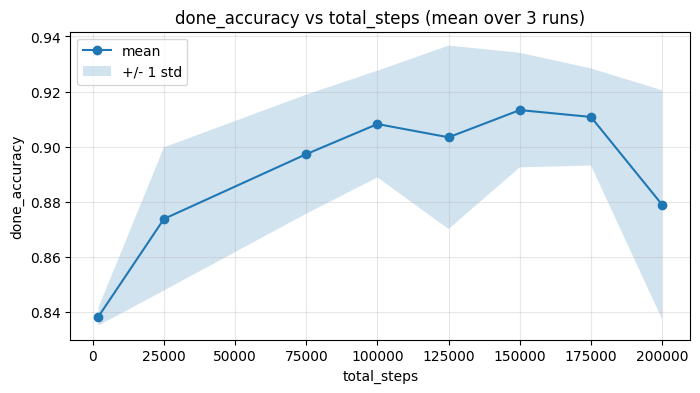

In [46]:
ep_models = train_list(ep_lst)
plot_accuracy_vs_variable(ep_models, "total_steps")

#### Exploring batch_size
- control : `batch_size = 32`
- bs1 : `batch_size = 16` (noisier, more frequent updates)
- bs2 : `batch_size = 64` (smoother, less frequent updates)
- Since the training set is only 500 episodes, very large batch sizes make each batch look increasingly similar from step to step (less diversity per gradient step), while very small batch sizes trade that off for noisier gradients.

In [47]:
bs1_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 16, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
bs2_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 48, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
bs3_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 64, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
bs4_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 80, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
bs5_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 96, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}
bs6_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 112, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 1}

bs_lst = [bs1_params, control_params, bs2_params, bs3_params, bs4_params, bs5_params, bs6_params]

In [48]:
bs_models = train_list(bs_lst)
plot_accuracy_vs_variable(bs_models, "batch_size")


--- Param set {'hidden_size': 128, 'n_gaussians': 5, 'n_epochs': 50, 'batches_per_epoch': 1000, 'batch_size': 16, 'seq_len': 29, 'capacity': 2000, 'loss_wt': 1, 'done_wt': 1} | Run 1/3 ---
Epoch   1/50 | MDN NLL: -5.6178 | Done BCE: 0.1954
Epoch   2/50 | MDN NLL: -6.6760 | Done BCE: 0.1838
Epoch   3/50 | MDN NLL: -5.8985 | Done BCE: 0.1694
Epoch   4/50 | MDN NLL: -8.2327 | Done BCE: 0.1459
Epoch   5/50 | MDN NLL: -8.7974 | Done BCE: 0.1421
Epoch   6/50 | MDN NLL: -9.7748 | Done BCE: 0.1319
Epoch   7/50 | MDN NLL: -8.3015 | Done BCE: 0.0877
Epoch   8/50 | MDN NLL: -9.9423 | Done BCE: 0.0597
Epoch   9/50 | MDN NLL: -10.4495 | Done BCE: 0.0478
Epoch  10/50 | MDN NLL: -9.8315 | Done BCE: 0.0421
Epoch  11/50 | MDN NLL: -9.9638 | Done BCE: 0.0379
Epoch  12/50 | MDN NLL: -10.8813 | Done BCE: 0.0341
Epoch  13/50 | MDN NLL: -11.2257 | Done BCE: 0.0316
Epoch  14/50 | MDN NLL: -11.4863 | Done BCE: 0.0270
Epoch  15/50 | MDN NLL: -10.5647 | Done BCE: 0.0220
Epoch  16/50 | MDN NLL: -11.7511 | Done 

KeyboardInterrupt: 

#### Exploring capacity
- `capacity` is the ceiling on the `buffer`'s ring buffer. `collect_rollouts()` collects `n_episodes=500` episodes by default, so with `capacity=2000` the buffer never actually fills up and `capacity` has *no effect at all* in the control run above.
- To make `capacity` meaningful, it has to be exercised against how many episodes are actually collected:
    - `cap1` : `capacity = 1000`, and 1000 episodes collected -> the buffer fills exactly, giving the model **2x** the training data of the control.
    - `cap2` : `capacity = 200`, and 500 episodes collected (same as control) -> since capacity is a ring buffer, only the **most recent 200** of those 500 episodes survive (older ones get overwritten), simulating a smaller effective dataset / catastrophic forgetting of older rollouts.
- Because `n_episodes` isn't a parameter of `train_list`/`DreamEnv.train`, a small helper `train_list_capacity` is defined below that also controls how many rollouts get collected before training.

In [ ]:
def train_list_capacity(params_list):
    """Same as train_list, but also controls how many episodes get collected,
    so that `capacity` can actually be exercised (bound or evict data)."""
    model_lst = []
    for param_set in params_list:
        n_episodes = param_set.get("n_episodes", 500)
        model = DreamEnv(env,
                         DynPriceReward,
                         env.max_steps,
                        capacity=param_set["capacity"],
                        hidden_size=param_set["hidden_size"],
                        n_gaussians=param_set["n_gaussians"],
                        temperature=1.0,
                        device="cpu",
                        done_threshold=0.5,
                        mdnloss_wt=param_set["loss_wt"],
                        doneloss_wt=param_set["done_wt"])
        episodes = model.buffer.collect_rollouts(n_episodes=n_episodes)
        model.buffer.add_many(episodes)
        trainedmodel = model.train(n_epochs=param_set["n_epochs"],
                                    batch_size=param_set["batch_size"],
                                    seq_len=param_set["seq_len"],
                                    lr=1e-3,
                                    batches_per_epoch=param_set["batches_per_epoch"],
                                    render=True
                                    )
        trainedmodel.run_config = dict(param_set)
        model_lst.append(trainedmodel)
    return model_lst

In [ ]:
control_cap_params = dict(control_params)
control_cap_params["n_episodes"] = 500  # matches collect_rollouts default; capacity=2000 never binds

cap1_params = {"hidden_size": 128, "n_gaussians": 5, "n_epochs": 20, "batches_per_epoch": 100,
               "batch_size": 32, "seq_len": env.max_steps - 1, "capacity": 1000, "loss_wt": 1,
               "done_wt": 1, "n_episodes": 2000}  # 2x capacity, so 1000 episodes get evicted
cap2_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 200, "loss_wt" : 1, 'done_wt' : 1,
                  "n_episodes" : 500}  # only the most recent 200 of the 500 collected episodes are retained

cap_lst = [control_cap_params, cap1_params, cap2_params]

In [ ]:
cap_models = train_list_capacity(cap_lst)
plot_accuracy_vs_variable(cap_models, "capacity")

____
#### Exploring loss weighting: loss_wt & done_wt
- `loss = loss_wt * loss_mdn + done_wt * loss_done`. The two weights are explored one at a time, holding the other at the control value of `1`, so each sweep still isolates a single variable for plotting.
- sweep A (`loss_wt`) raises the emphasis on **state prediction accuracy** — expect `state_mae` to trend down as `loss_wt` increases, possibly at some cost to `done_accuracy`.
- sweep B (`done_wt`) raises the emphasis on **episode-termination accuracy** — expect `done_accuracy` to trend up as `done_wt` increases, possibly at some cost to `state_mae`.

In [ ]:
lw0_params = {"hidden_size": 128, "n_gaussians": 5, "n_epochs": 20, "batches_per_epoch": 100,
              "batch_size": 32, "seq_len": env.max_steps - 1, "capacity": 2000, "loss_wt": 0.5, "done_wt": 1}

lw1_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 2, 'done_wt' : 1}

lw2_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 5, 'done_wt' : 1}

loss_wt_lst = [lw0_params, control_params, lw1_params, lw2_params]  # 0.5, 1, 2, 5

In [ ]:
loss_wt_models = train_list(loss_wt_lst)
plot_accuracy_vs_variable(loss_wt_models, "loss_wt", metric_name="state_mae")

In [ ]:
dw0_params = {"hidden_size": 128, "n_gaussians": 5, "n_epochs": 20, "batches_per_epoch": 100,
              "batch_size": 32, "seq_len": env.max_steps - 1, "capacity": 2000, "loss_wt": 1, "done_wt": 0.5}

dw1_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 2}
dw2_params = {"hidden_size" : 128, "n_gaussians" : 5, "n_epochs" : 50, "batches_per_epoch" : 1000,
                  "batch_size" : 32, "seq_len" : env.max_steps - 1,  "capacity" : 2000, "loss_wt" : 1, 'done_wt' : 5}

done_wt_lst = [dw0_params, control_params, dw1_params, dw2_params]  # 0.5, 1, 2, 5

In [ ]:
done_wt_models = train_list(done_wt_lst)
plot_accuracy_vs_variable(done_wt_models, "done_wt", metric_name="done_accuracy")